### Librerias

In [195]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import kagglehub
from kagglehub import KaggleDatasetAdapter
from matplotlib.pyplot import title

### Importamos Datos Desde Kaggle

In [196]:
file_path = "train.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shuofxz/titanic-machine-learning-from-disaster",
  file_path,
)

/tmp/ipykernel_19333/4093734573.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [197]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Limpieza de Columna Edad (Age)
- Relleno de nulos con una heuristica del titulo del nombre del pasajero

    ~ Mr o Mrs -> Un rango de edad entre 35 y 85. Cualquier otro titulo lo asignamos como 'Jovenes' con un rango entre 20 y 32
    
- Conversion de tipo de dato de columna float -> int 

In [198]:
for i in df['Name']:
    if 'Mr' or 'Mrs':
        df['Age'] = df['Age'].fillna(np.random.randint(35,85))
    else:
        df['Age'] = df['Age'].fillna(np.random.randint(20,32))

In [199]:
df['Age'] = df['Age'].astype('int')

### Limpieza de columna cabin

- Relleno de valores faltantes con la moda ('B96 B98')

In [200]:
df['Cabin'].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [201]:
df['Cabin'].mode()[0]

'B96 B98'

In [202]:
df['Cabin'] = df['Cabin'].fillna(df['Cabin'].mode()[0])

### Limpieza de columna Embarked

- Unicamente 2 filas con valores nulos por lo cual rellenamos por la  moda ('S')

In [203]:
df.Embarked.unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [204]:
df['Embarked'].mode()[0]

'S'

In [205]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

### Conversion a Variables Categoricas

- Sustituimos la columna sexo por valores binarios 0 para las mujeres y 1 para los hombres.
- Convertimos la columna sexo en tipo categorica

In [206]:
df.Sex.unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [207]:
df['Sex'] = np.where(df['Sex'] == 'female', 0, 1)

In [208]:
df['Sex'].unique()

array([1, 0])

In [209]:
#df['Sex'] = df['Sex'].astype('category')

In [210]:
df['Pclass'] = df['Pclass'].astype('str')

In [211]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    str    
 3   Name         891 non-null    str    
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    int64  
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(1), int64(6), str(5)
memory usage: 83.7 KB


#### Agrupamiento por sexo 

In [212]:
vivos = df.groupby('Sex')['Survived'].sum()

In [213]:
vivos

Sex
0    233
1    109
Name: Survived, dtype: int64

(0.0, 250.0)

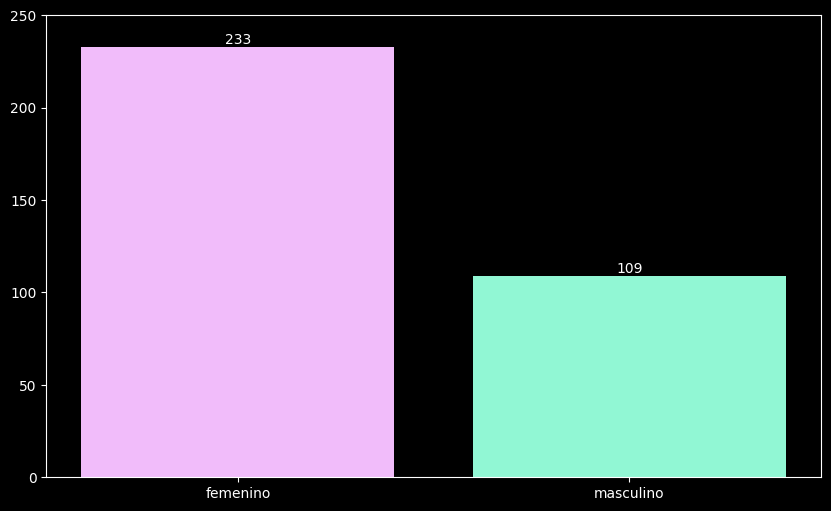

In [214]:
fig, ax = plt.subplots(figsize=(10,6))
barra = ax.bar(['femenino', 'masculino'],
               vivos.values,
               color=['#F1BCFA','#91F7D4'])
ax.bar_label(barra)
ax.set_ylim(0,250)

##### Observamos segun el diagrama de barras que la diferencia de sobrevivientes entre mujeres y hombres es casi la mitad, lo cual siempre se entiendo que en caso de crisis o emergencias las mujeres y niños tienen prioridad, en este caso para subir a los botes salvavidas que habian en el barco.

### Comparacion de Sobrevivientes por Clases

In [215]:
sobrevivientes_clases = df.groupby('Pclass')['Survived'].sum()

In [216]:
sobrevivientes_clases

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64

In [217]:
label_clase =['Primera Clase','Segunda Clase','Tercera Clase']

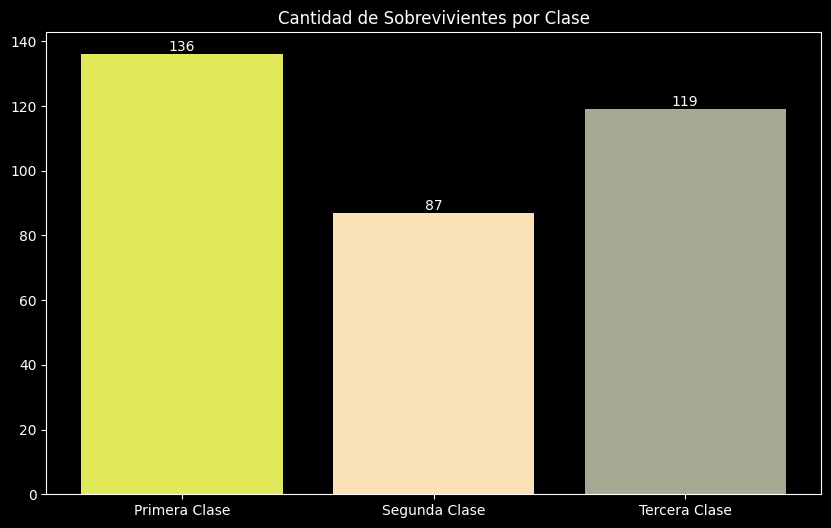

In [218]:
fig, ax = plt.subplots(figsize=(10,6))
barra = ax.bar(label_clase,
               sobrevivientes_clases.values,
               color=['#E1E85A', '#FAE2B6', '#A7A894'])
plt.title('Cantidad de Sobrevivientes por Clase')
ax.bar_label(barra)
plt.show()

##### En este Grafico de Barras observamos que la cantidad de sobrevivientes del Titanic fueron:

1. Primera Clase 
2. Tercera Clase
3. Segunda Clase

Este hace sentido si indagamos en la posicion en las que se encontraban esta clases distribuidas en el barco, los de primera clase ubicados en la zona centrica y superior del barco se les hizo mucho mas facil poder moverse para llegar a los botes de emergencias. Con esa misma logica podriamos pensar que los de la segunda clase podrian seguir como los segundos a nivel de sobrevivientes pero no, esto debido a que estos se encontraban aunque no en la zona inferior en la parte de atras del barco (Popa), mientras que la Tercera Clase estaba dividida entre los extremos Proa y Popa

In [219]:
total_por_clase = df.groupby('Pclass')['Survived'].count()

In [220]:
total_por_clase

Pclass
1    216
2    184
3    491
Name: Survived, dtype: int64

Text(0.5, 1.0, 'Total de Personas por Clase')

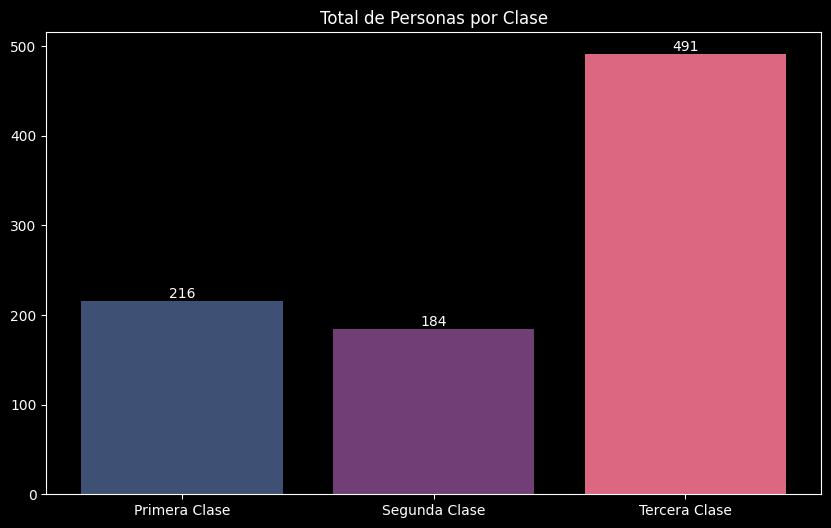

In [221]:
fig, ax = plt.subplots(figsize=(10,6))
barra = ax.bar(label_clase,
               total_por_clase.values,
               color=['#3F5075','#713F75','#DB6781'] )
ax.bar_label(barra)
plt.title('Total de Personas por Clase')

##### Habiendo visto el diagrama de Barras anterior pudieramos suponer que el porcentaje de sobrevivientes en la tercera clase fue mucho mayor que la segunda, pero nada mas alejado de la realidad. A comparacion de las demas clases esta fue la que tuvo la diferencia mas grande entre las 3, relacion cantidad-Sobrevivientes

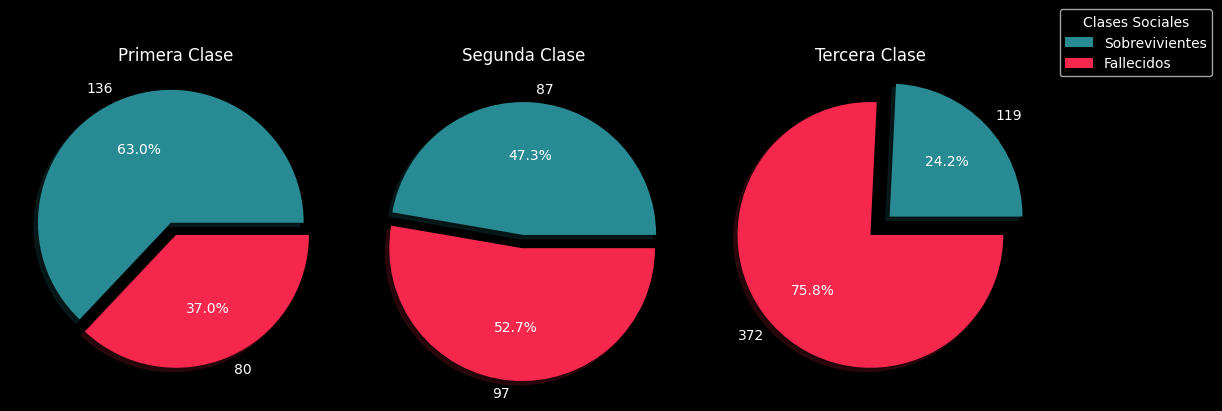

In [369]:
fig, ax = plt.subplots(1,3,figsize=(12,10))
ax[0].pie([sobrevivientes_clases['1'], total_por_clase['1'] - sobrevivientes_clases['1']],
       colors=['#288B94','#F5274D'],
       shadow=True,
       autopct='%1.1f%%',
       labels=[sobrevivientes_clases['1'], total_por_clase['1'] - sobrevivientes_clases['1']],
       explode=[0.1,0]
       )
ax[1].pie([sobrevivientes_clases['2'], total_por_clase['2'] - sobrevivientes_clases['2']],
       colors=['#288B94','#F5274D'],
       shadow=True,
       labels=[sobrevivientes_clases['2'], total_por_clase['2'] - sobrevivientes_clases['2']],
       autopct='%1.1f%%',
       explode=[0,0.1]
       )
ax[2].pie([sobrevivientes_clases['3'], total_por_clase['3'] - sobrevivientes_clases['3']],
       colors=['#288B94','#F5274D'],
       shadow=True,
       labels=[sobrevivientes_clases['3'], total_por_clase['3'] - sobrevivientes_clases['3']],
       autopct='%1.1f%%',
       explode=[0.2,0]
       )
ax[0].set_title('Primera Clase')
ax[1].set_title('Segunda Clase')
ax[2].set_title('Tercera Clase')
plt.legend(['Sobrevivientes', 'Fallecidos'], title="Clases Sociales", loc='upper right', bbox_to_anchor=(1.55,1.2))
plt.tight_layout()
plt.show()

##### En estos diagramas de pastel obsevamos el porcentaje y la cantidad de personas que sobrevivieron y fallecieron al Titanic, dividido por clases.
- Primera Clase: La segunda con mas personas a bordo, con un 37% de fallecidos repectivamente
- Segunda Clase: La que tenia menos personas a bordo y con un 52.7% obsevamos que mas de la mitad de esta clase fallecio en el hundimiento por su posicion en el barco (Popa)
- Tercera Clase: Con diferncia la que poseia el mayor numero de personas a bordo, con un 75.8% se queda con la que mas tuvo fallecidos, esto debido a que estos se encontraban en la parte inferior del barco y se les hizo mas tardio que a las demas clases moverse con velocidad a los botes de emergencias.

In [321]:
f_class = df[df['Sex'] == 0].iloc[df['Pclass'] == '1']

In [344]:
sobrevivientes_femeninas = f_class['Survived'].iloc[f_class['Survived'] == 1].sum()

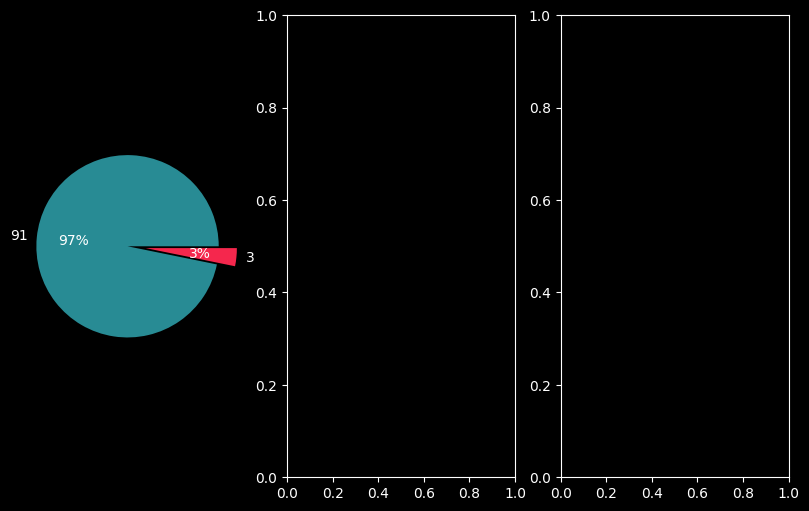

In [373]:
fig, ax = plt.subplots(1,3,figsize=(10,6))
ax[0].pie([f_class['Survived'].iloc[f_class['Survived'] == 1].sum(), f_class['Survived'].iloc[f_class['Survived'] == 0].count()],
       labels=  [f_class['Survived'].iloc[f_class['Survived'] == 1].sum(), f_class['Survived'].iloc[f_class['Survived'] == 0].count()],
       colors=['#288B94','#F5274D','#852894'],
       explode=[0,0.2],
       autopct='%1.f%%'
       )
plt.show()

### Creacion de Pipeline y Transformador de Columnas para el entrenamiento del modelo

##### Separacion de la data

In [225]:
y = df['Survived']
X = df.drop('Survived', axis=1)

In [226]:
type(y)

pandas.Series

##### Column Transformer

In [227]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import OrdinalEncoder

##### Seleccion manual de Metodo de Preprocesamiento segun la cantidad de valores unicos que posee

- Ordinal Encoder = Psclass nos dice la clase del boleto primera, segunda y tercera en esa misma jerarquia.
- One Hot 

In [228]:
#e = sk.preprocessing.OrdinalEncoder(categories=[['3','2','1']])
#X['Datos'] = e.fit_transform(X[['Pclass']])

In [229]:
tran = sk.compose.ColumnTransformer(transformers=[('columnas_con_gerarquia', OrdinalEncoder(categories=[['3','2','1']]), ['Pclass']),
                                                  ('columnas_poca_categorias', OneHotEncoder(handle_unknown='ignore'), ['Embarked']), 
                                                  ('columnas_muchas_categorias', TargetEncoder(), ['Cabin', 'Name', 'Ticket'])], remainder='passthrough')

In [230]:
model = sk.ensemble.RandomForestClassifier(n_estimators=130, verbose=1)

In [231]:
pipeline = sk.pipeline.Pipeline(steps=[('Preprocesamiento', tran),
                                       ('Modelo', model)])

In [232]:
pipeline.fit(X,y)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 130 out of 130 | elapsed:    0.5s finished


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Preprocesamiento', ...), ('Modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('columnas_con_gerarquia', ...), ('columnas_poca_categorias', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, 